In [3]:
import cv2
import matplotlib.pyplot as plt
import os

In [4]:
# Haar Cascade URLs
face_link = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
eye_link = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml"

# Download Cascade Files if they don't exist
if not os.path.isfile("face.xml"):
    !wget -O face.xml {face_link}

if not os.path.isfile("eye.xml"):
    !wget -O eye.xml {eye_link}

In [5]:
# Load Classifiers
face_detector = cv2.CascadeClassifier("face.xml")
eye_detector = cv2.CascadeClassifier("eye.xml")

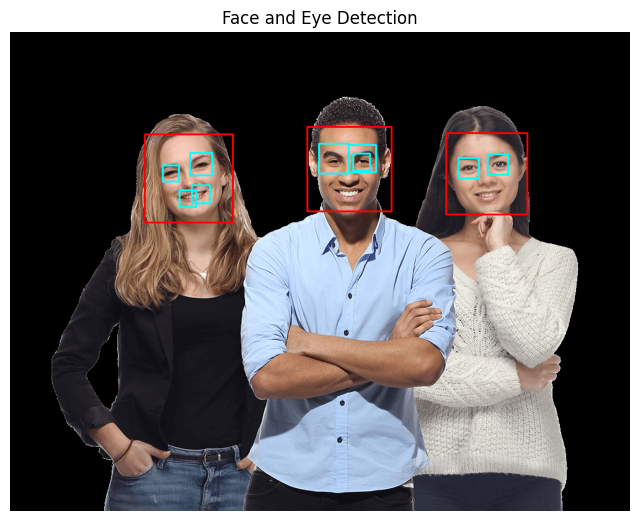

In [6]:
# Read Image using the provided path
image_path = "/content/1621069124_250038.png"
image = cv2.imread(image_path)

# Check if image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}. Please check the image path and file.")
else:
    # Convert to Grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect Faces
    detected_faces = face_detector.detectMultiScale(gray_image, scaleFactor=1.2, minNeighbors=4)

    # Draw Rectangles around faces and eyes
    for (x, y, w, h) in detected_faces:

        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)

        gray_face = gray_image[y:y+h, x:x+w]
        color_face = image[y:y+h, x:x+w]

        detected_eyes = eye_detector.detectMultiScale(gray_face, scaleFactor=1.1, minNeighbors=3)

        for (ex, ey, ew, eh) in detected_eyes:
            cv2.rectangle(color_face, (ex, ey), (ex + ew, ey + eh), (255, 255, 0), 2)

    # Display Output
    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Face and Eye Detection")
    plt.axis("off")
    plt.show()